In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,roc_auc_score
df=pd.read_csv(r"D:\Python and R\Python\Lending_Club_Loan_Default\lending_club_loan_two.csv")


In [9]:
df.shape

(396030, 27)

In [13]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [21]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [25]:
df['loan_status'].value_counts(normalize=True)*100

loan_status
Fully Paid     80.387092
Charged Off    19.612908
Name: proportion, dtype: float64

In [29]:
df.isnull().sum().sort_values(ascending=False)

mort_acc                37795
emp_title               22927
emp_length              18301
title                    1756
pub_rec_bankruptcies      535
revol_util                276
loan_amnt                   0
dti                         0
application_type            0
initial_list_status         0
total_acc                   0
revol_bal                   0
pub_rec                     0
open_acc                    0
earliest_cr_line            0
purpose                     0
term                        0
loan_status                 0
issue_d                     0
verification_status         0
annual_inc                  0
home_ownership              0
sub_grade                   0
grade                       0
installment                 0
int_rate                    0
address                     0
dtype: int64

In [33]:
df.sample(5)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
120674,2875.0,36 months,19.99,106.84,E,E1,NaN,4 years,MORTGAGE,201700.0,...,8.0,0.0,4531.0,75.5,12.0,w,INDIVIDUAL,0.0,0.0,"27025 Paul Underpass\nParksborough, IL 86630"
307708,12000.0,36 months,10.74,391.39,B,B4,United Parcel Services,3 years,RENT,100000.0,...,4.0,0.0,38708.0,85.1,6.0,f,INDIVIDUAL,NaN,0.0,44172 Peters Fort Suite 249\nLake Douglasville...
315308,12000.0,60 months,13.99,279.16,C,C4,Meals RIS,10+ years,MORTGAGE,90000.0,...,20.0,0.0,4007.0,12.5,30.0,w,INDIVIDUAL,2.0,0.0,"9905 Wade Highway\nLake Danamouth, RI 70466"
159737,20000.0,60 months,14.09,466.30,B,B5,Air Force,10+ years,MORTGAGE,85000.0,...,12.0,0.0,21283.0,47.5,34.0,f,INDIVIDUAL,3.0,0.0,"40668 James Manors\nNew Andreamouth, MI 70466"
32096,3800.0,36 months,5.79,115.25,A,A2,Examinetics,3 years,MORTGAGE,30000.0,...,10.0,0.0,177.0,1.2,29.0,f,INDIVIDUAL,NaN,0.0,610 Fitzpatrick Port Apt. 894\nNorth Emilybury...


In [37]:
(df.isnull().sum()>0).sum()

6

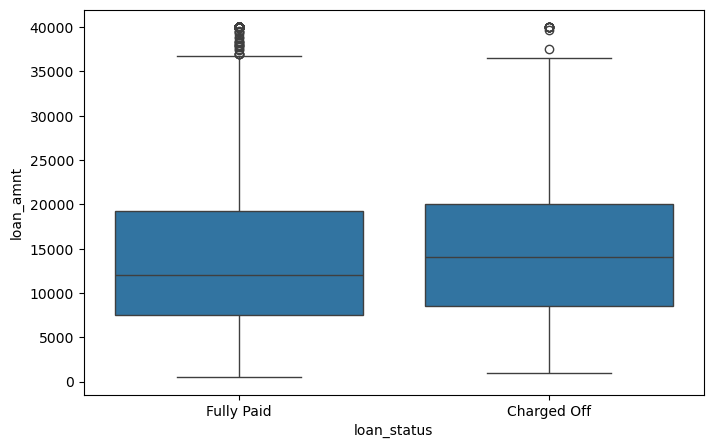

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_status',y='loan_amnt',data=df)
plt.show()

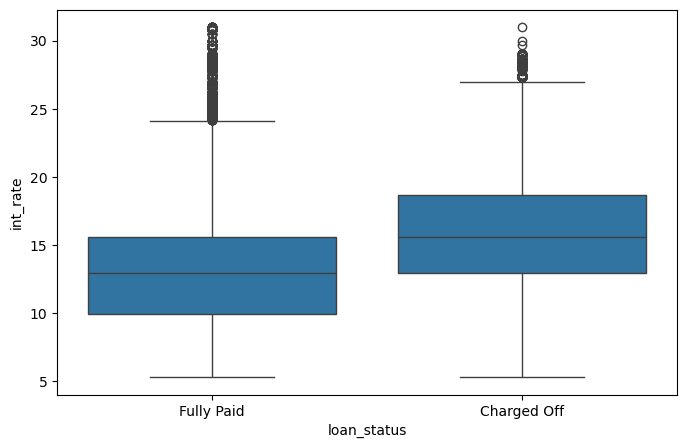

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_status',y='int_rate',data=df)
plt.show()

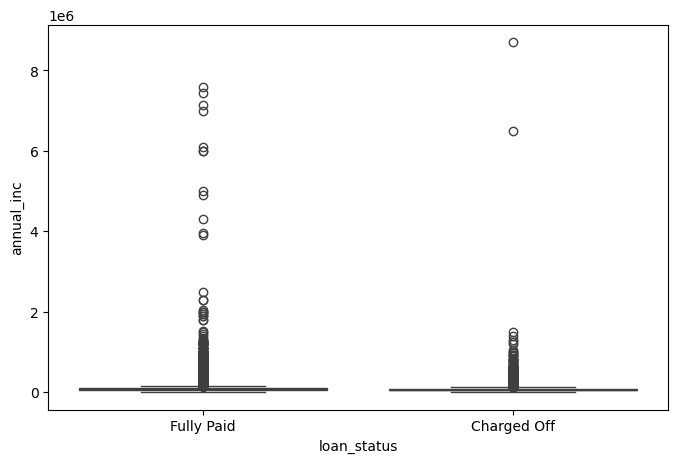

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_status',y='annual_inc',data=df)
plt.show()

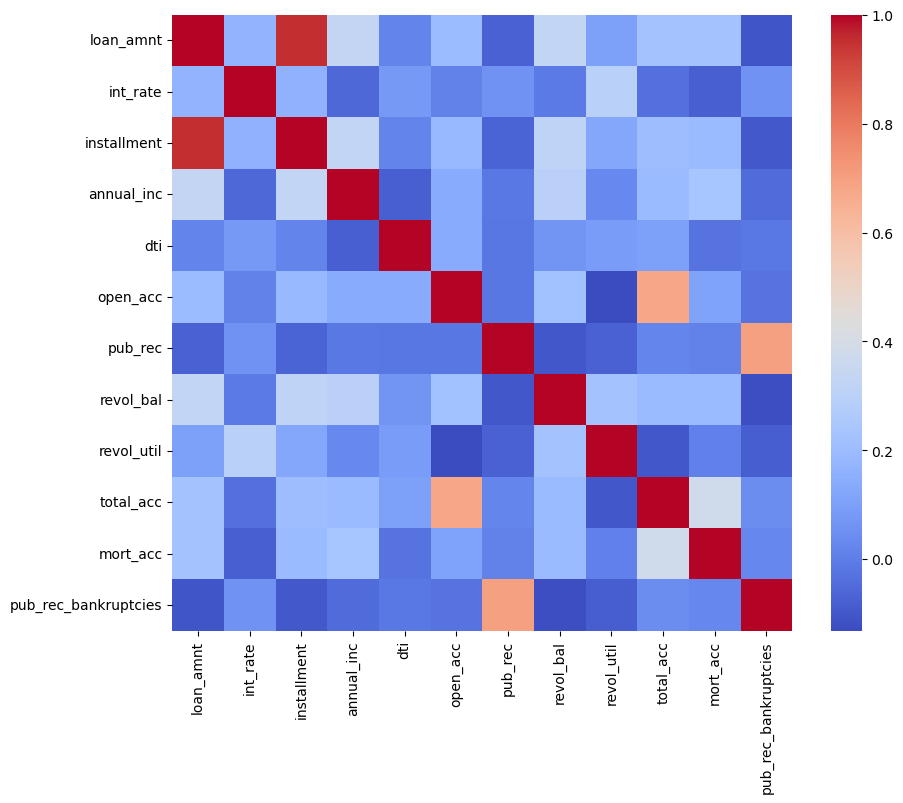

In [53]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')
plt.show()            

In [85]:
df['emp_length'].unique()

array([10.,  4.,  0.,  6.,  9.,  2.,  3.,  8.,  7.,  5.,  1., nan])

In [81]:
df['emp_length']=df['emp_length'].str.replace('years','')
df['emp_length']=df['emp_length'].str.replace('year','')
df['emp_length']=df['emp_length'].str.replace('+','')
df['emp_length']=df['emp_length'].str.replace('< 1','0')
df['emp_length']=df['emp_length'].astype(float)

AttributeError: Can only use .str accessor with string values!

In [89]:
df[['mort_acc','total_acc']].corr()

,mort_acc,total_acc
mort_acc,1.000000,0.381072
total_acc,0.381072,1.000000


In [93]:
df.nunique().sort_values(ascending=False).head(20)

address                 393700
emp_title               173105
installment              55706
revol_bal                55622
title                    48816
annual_inc               27197
dti                       4262
loan_amnt                 1397
revol_util                1226
earliest_cr_line           684
int_rate                   566
total_acc                  118
issue_d                    115
open_acc                    61
sub_grade                   35
mort_acc                    33
pub_rec                     20
purpose                     14
emp_length                  11
pub_rec_bankruptcies         9
dtype: int64

In [97]:
df.drop('emp_title',axis=1,inplace=True)

KeyError: "['emp_title'] not found in axis"

In [101]:
df['loan_income_ratio']=df['loan_amnt']/df['annual_inc']

In [105]:
df.groupby('loan_status')['loan_income_ratio'].mean()

loan_status
Charged Off         inf
Fully Paid     0.205222
Name: loan_income_ratio, dtype: float64

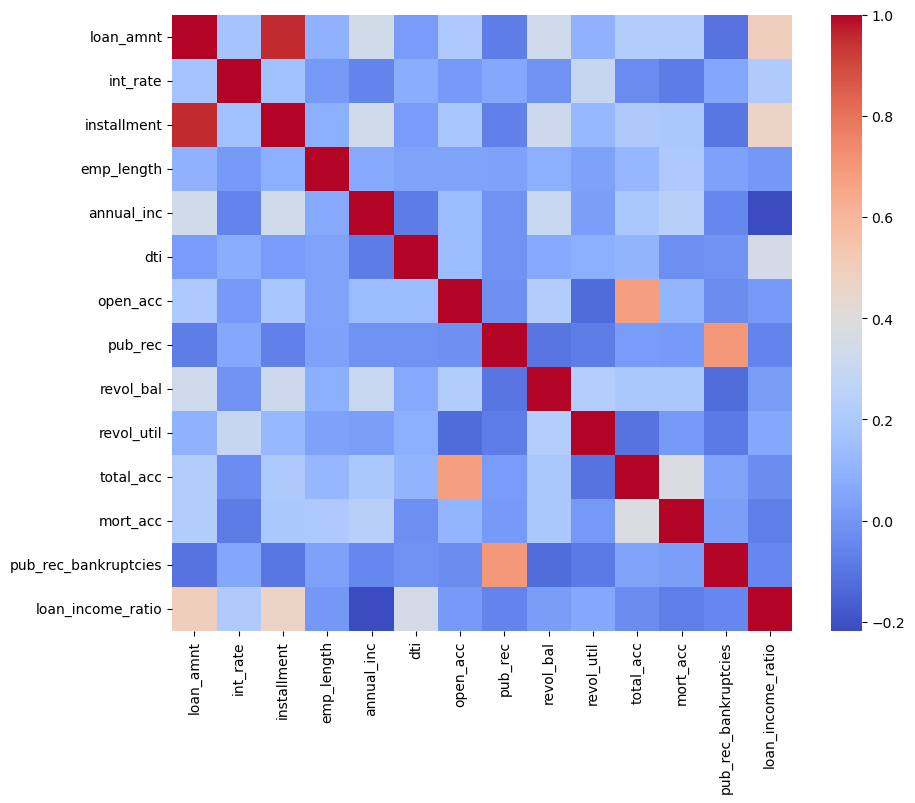

In [109]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')
plt.show()

In [113]:
y=df['loan_status']
X=df.select_dtypes(include=np.number)
X=X.fillna(X.median())
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(classification_report(y_test,y_pred))

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ValueError: Input X contains infinity or a value too large for dtype('float64').

In [118]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
model=LogisticRegression(max_iter=5000,class_weight='balanced')
model.fit(X_train,y_train)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


ValueError: Input X contains infinity or a value too large for dtype('float64').

In [122]:
y_pred=model.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
y_prob=model.predict_proba(X_test)[:,1]
print("ROC-AUC:",roc_auc_score(y_test,y_prob))

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [126]:
feature_names=X.columns
coef_df=pd.DataFrame({
    "Feature": feature_names,
    "Coefficient":model.coef_[0]
})
coef_df=coef_df.sort_values(by="Coefficient",ascending=False)
coef_df.head(10)
coef_df.tail(10)

,Feature,Coefficient
13,loan_income_ratio,0.007411
9,revol_util,0.006545
12,pub_rec_bankruptcies,0.003079
2,installment,0.002381
4,annual_inc,0.000011
8,revol_bal,-0.000004
0,loan_amnt,-0.000090
7,pub_rec,-0.002301
5,dti,-0.006805
1,int_rate,-0.031160


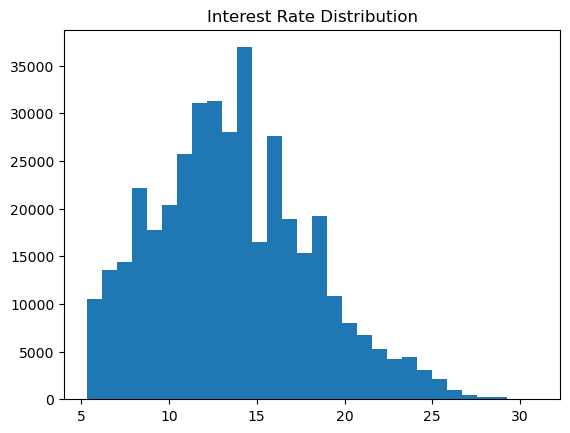

In [130]:
import matplotlib.pyplot as plt
plt.hist(df['int_rate'],bins=30)
plt.title("Interest Rate Distribution")
plt.show()

In [134]:
from sklearn.preprocessing import StandardScaler
features=["int_rate","dti","revol_util"]
scaler=StandardScaler()
scaled_values=scaler.fit_transform(df[features])
df_scaled=pd.DataFrame(scaled_values,columns=features)
df["risk_score"]=df_scaled.sum(axis=1)

In [138]:
df["risk_tier"]=pd.qcut(df["risk_score"],
                        q=3,
                        labels=["Low Risk","Medium Risk","High Risk"])

In [142]:
pd.crosstab(df["risk_tier"],
            df["loan_status"],
            normalize="index")

loan_status,Charged Off,Fully Paid
risk_tier,,
Low Risk,0.104151,0.895849
Medium Risk,0.187304,0.812696
High Risk,0.296932,0.703068


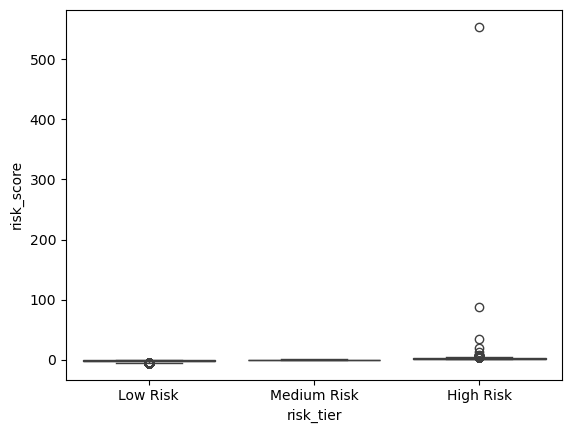

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure()
sns.boxplot(x="risk_tier",y="risk_score",data=df)
plt.show()

In [150]:
df_stress=df.copy()
df_stress["dti"]=df_stress["dti"]*1.10
df_stress["revol_util"]=df_stress["revol_util"]*1.10
df_stress["annual_inc"]=df_stress["annual_inc"]*0.95

In [154]:
scaled_stress=scaler.transform(df_stress[features])
df_stress_scaled=pd.DataFrame(scaled_stress,columns=features)
df_stress["risk_score_stress"]=df_stress_scaled.sum(axis=1)

In [158]:
print("Average Risk(Original):",df["risk_score"].mean())
print("Average Risk(Stress):",df_stress["risk_score_stress"].mean())

Average Risk(Original): -1.0768571825447874e-16
Average Risk(Stress): 0.3162850563728869


In [162]:
df_stress["risk_tier_stress"]=pd.qcut(df_stress["risk_score_stress"],
                        q=3,
                        labels=["Low Risk","Medium Risk","High Risk"])
pd.crosstab(df["risk_tier"],df_stress["risk_tier_stress"])

risk_tier_stress,Low Risk,Medium Risk,High Risk
risk_tier,,,
Low Risk,130206,1804,0
Medium Risk,1804,128182,2024
High Risk,0,2024,129986


In [166]:
safe_df=df[df["loan_status"]=="Fully Paid"]

In [170]:
safe_df[["int_rate","annual_inc","dti","revol_util"]].mean()

int_rate         13.092105
annual_inc    75829.951566
dti              16.824010
revol_util       52.796918
dtype: float64

In [174]:
df[["int_rate","annual_inc","dti","revol_util"]].mean()

int_rate         13.639400
annual_inc    74203.175798
dti              17.379514
revol_util       53.791749
dtype: float64

In [178]:
df.sort_values("risk_score").head(int(len(df)*0.1))

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address,loan_income_ratio,risk_score,risk_tier
45880,20000.0,36 months,5.32,602.30,A,A1,10.0,MORTGAGE,100000.0,Not Verified,...,0.0,23.0,f,INDIVIDUAL,2.0,0.0,"PSC 5401, Box 4266\nAPO AE 29597",0.200000,-5.024652,Low Risk
156648,4400.0,36 months,5.32,132.51,A,A1,6.0,MORTGAGE,49000.0,Verified,...,0.1,7.0,w,INDIVIDUAL,1.0,0.0,"73924 Justin Unions Apt. 284\nEast Jesse, KY 0...",0.089796,-5.009463,Low Risk
175506,12000.0,36 months,5.32,361.38,A,A1,10.0,RENT,97000.0,Verified,...,0.0,32.0,w,INDIVIDUAL,0.0,0.0,"682 Fisher Divide\nWilliamsfort, SD 22690",0.123711,-5.007448,Low Risk
15409,12000.0,36 months,5.32,361.38,A,A1,7.0,MORTGAGE,77000.0,Verified,...,0.2,27.0,w,INDIVIDUAL,3.0,0.0,"56714 Arnold Island\nMelissaborough, IN 05113",0.155844,-4.994829,Low Risk
238852,9500.0,36 months,5.32,286.10,A,A1,8.0,MORTGAGE,170000.0,Not Verified,...,0.0,15.0,w,INDIVIDUAL,3.0,0.0,"7155 David Lake\nRalphview, NJ 29597",0.055882,-4.985249,Low Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353671,12600.0,36 months,9.17,401.68,B,B2,10.0,RENT,42000.0,Source Verified,...,28.9,16.0,w,INDIVIDUAL,0.0,0.0,"494 Stacy Throughway\nJohnsonview, MA 22690",0.300000,-2.384169,Low Risk
292278,20000.0,36 months,6.03,608.72,A,A1,4.0,MORTGAGE,99500.0,Source Verified,...,49.0,22.0,w,INDIVIDUAL,5.0,0.0,"612 Kristi Locks\nLake John, WY 48052",0.201005,-2.384151,Low Risk
122311,27600.0,36 months,7.62,860.06,A,A3,10.0,MORTGAGE,97000.0,Verified,...,25.0,26.0,f,INDIVIDUAL,3.0,0.0,"83606 Daryl Summit\nNew James, NM 29597",0.284536,-2.384123,Low Risk
128263,15000.0,60 months,10.36,321.37,B,B5,8.0,MORTGAGE,67000.0,Verified,...,3.6,32.0,f,INDIVIDUAL,NaN,0.0,USNV Smith\nFPO AE 48052,0.223881,-2.384121,Low Risk


In [182]:
y_test=y_test.map({
    "Fully Paid":0,
    "Charged Off":1
})

In [186]:
print(y_test.unique())
print(y_test.dtype)

[nan]
float64


In [190]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix
y_proba=model.predict_proba(X_test)[:,1]

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [194]:
threshold=[0.3,0.4,0.5,0.6,0.7]
results=[]
for thresh in threshold:
    y_pred_thresh=(y_proba>=thresh).astype(int)
    precision=precision_score(y_test,y_pred_thresh)
    recall=recall_score(y_test,y_pred_thresh)
    f1=f1_score(y_test,y_pred_thresh)
    tn,fp,fn,tp=confusion_matrix(y_test,y_pred_thresh).ravel()
    results.append({
    "Threshold":thresh,
    "Precision":precision,
    "Recall":recall,
    "F1 score":f1,
    "True Positives":tp,
    "False Positives":fp,
    "False Negatives":fn,
    "True Negatives":tn
    })
results_df=pd.DataFrame(results)
results_df

NameError: name 'y_proba' is not defined

In [198]:
import matplotlib.pyplot as plt
threshold_range=np.arange(0.1,0.9,0.1)
print(threshold_range)
print(len(threshold_range))

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8]
8


In [202]:
precisions=[]
recalls=[]
for thresh in threshold_range:
    y_pred_thresh=(y_proba>=thresh).astype(int)
    precisions.append(precision_score(y_test,y_pred_thresh,zero_division=0))
    recalls.append(recall_score(y_test,y_pred_thresh,zero_division=0))
    print(len(threshold_range))
    print(len(precisions))
    print(len(recalls))

NameError: name 'y_proba' is not defined

ValueError: x and y must have same first dimension, but have shapes (8,) and (0,)

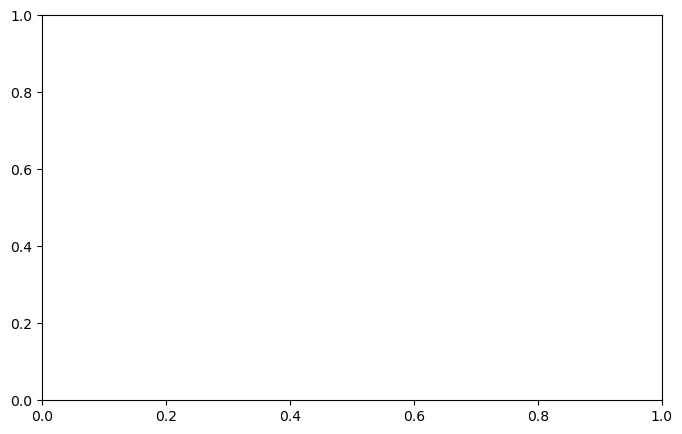

In [206]:
plt.figure(figsize=(8,5))
plt.plot(threshold_range,precisions,label="Precision")
plt.plot(threshold_range,recalls,label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()

In [208]:
cost_results = []
for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    total_cost = (fn * 5) + (fp * 1)
    cost_results.append({
        "Threshold": thresh,
        "Total Cost": total_cost
    })
cost_df = pd.DataFrame(cost_results)
cost_df

NameError: name 'thresholds' is not defined